FAST-FOOD DRIVE-THRU SIMULATION
----------------------------------------
Average Order Wait Time   = 67.65
Average Payment Wait Time = 1.22
Average Pickup Wait Time  = 18.15

System Bottleneck = Order


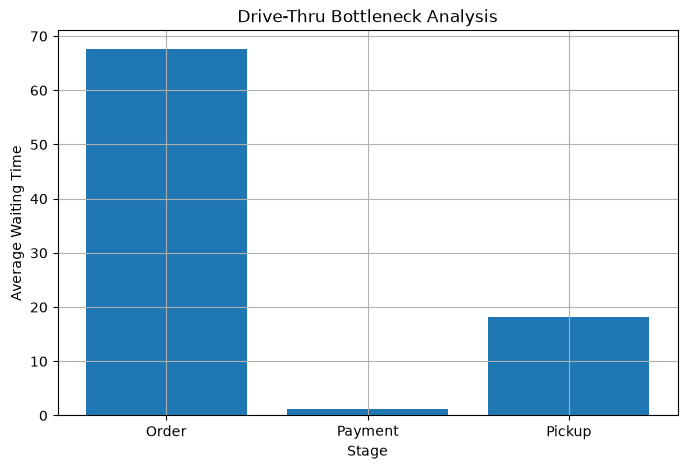

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------
# Parameters
# ---------------------------------

NUM_CUSTOMERS = 100

MEAN_ORDER_TIME = 2
MEAN_PAYMENT_TIME = 1
MEAN_PICKUP_TIME = 3

# ---------------------------------
# Variables
# ---------------------------------

order_waits = []
payment_waits = []
pickup_waits = []

order_finish = 0
payment_finish = 0
pickup_finish = 0

# ---------------------------------
# Simulation
# ---------------------------------

for customer in range(NUM_CUSTOMERS):

    # Customer arrival
    arrival = customer

    # ----- Order Station -----
    order_start = max(arrival, order_finish)
    order_wait = order_start - arrival

    order_service = np.random.exponential(
        MEAN_ORDER_TIME
    )

    order_finish = order_start + order_service

    # ----- Payment Window -----
    payment_start = max(
        order_finish,
        payment_finish
    )

    payment_wait = payment_start - order_finish

    payment_service = np.random.exponential(
        MEAN_PAYMENT_TIME
    )

    payment_finish = (
        payment_start + payment_service
    )

    # ----- Pickup Window -----
    pickup_start = max(
        payment_finish,
        pickup_finish
    )

    pickup_wait = pickup_start - payment_finish

    pickup_service = np.random.exponential(
        MEAN_PICKUP_TIME
    )

    pickup_finish = (
        pickup_start + pickup_service
    )

    order_waits.append(order_wait)
    payment_waits.append(payment_wait)
    pickup_waits.append(pickup_wait)

# ---------------------------------
# Results
# ---------------------------------

avg_order_wait = np.mean(order_waits)
avg_payment_wait = np.mean(payment_waits)
avg_pickup_wait = np.mean(pickup_waits)

print("FAST-FOOD DRIVE-THRU SIMULATION")
print("-" * 40)

print("Average Order Wait Time   =", round(avg_order_wait, 2))
print("Average Payment Wait Time =", round(avg_payment_wait, 2))
print("Average Pickup Wait Time  =", round(avg_pickup_wait, 2))

# Identify Bottleneck
waits = {
    "Order": avg_order_wait,
    "Payment": avg_payment_wait,
    "Pickup": avg_pickup_wait
}

bottleneck = max(waits, key=waits.get)

print("\nSystem Bottleneck =", bottleneck)

# ---------------------------------
# Visualization
# ---------------------------------

stages = ["Order", "Payment", "Pickup"]
avg_waits = [
    avg_order_wait,
    avg_payment_wait,
    avg_pickup_wait
]

plt.figure(figsize=(8,5))
plt.bar(stages, avg_waits)

plt.xlabel("Stage")
plt.ylabel("Average Waiting Time")
plt.title("Drive-Thru Bottleneck Analysis")
plt.grid(True)

plt.show()